# **ABSTRACT**
In this assignment, we will develop and explore two learning-based models that will be used to identify fraud detection. These models will be trained on a provided, heavily imbalanced, dataset (<<1% fraud). Two decision thresholds are then determined such that they achieve target false-alarm rates. Finally, calibration will be applied to account for the data imbalance.

# **Task C.1 - Model Development**

## Model Selection
The supervised models that we will be using are 
- Logistic Regression
    - Simple, but possibly still effective model.
    - Typically poor performance on complicated, non-linear patterns. This might motivate more complex models such as random forest. However, we believe starting with a basic model gives us the necessary insight to benchmark a more sophisticated, higher-performing model later.
- Random Forest
    - This method is chosen for its high robustness and strength against overfitting compared it a singular decision tree. Although it is more computationally expensive than logistic regression, 

Although our datasat might have complex and nonlinear patterns, its size and complexity does not necessitate neural networks, since it would be  overcomplicated and unnecessary. 

## Data Splitting
We considered several well-known splitting methods listed below. The  _italicized_ method is how we first partition the data into a train/validation split and the **bolded** method is how we perform cross-validation on the training data set for hyperparameter tuning. Note that we are given highly imbalanced (<<1% fraud) data.
- Random Splitting: Randomly assign samples to train and test sets. Simple, quick, and easy to implement but not suitable for imbalanced datasets since it disregards any data characteristics.
- Temporal Splitting: Divides data by time. Earlier data samples train model and later samples validate model. Preserves real-world ordering where past events are used to predict future events. However, not suitable for data where there is no time dependency. 
- Stratified Splitting: Divides data into groups (strata) so that class distribution is preserved all training/validation sets. Highly suitable for imbalanced data.
    - _Stratified Random Splitting_: Split data once, randomly, while preserving class ratios. Simple, fast but results heavily depend on random split. Good for imbalanced data by virtue of stratification. 
    - **Stratified $K$-Fold Splitting**: Divide data into $K$ folds. Train and validate $K$ times such that every data sample appears in validation exactly once. Computationally expensive, but given that the dataset is not millions of parameters, suitable for cross-validation.
    
We are given two different datasets to develop our model. One balanced dataset that will be used for exploratory work and an imbalanced dataset that will be used to train the final model.

We need to decide how to split our data in terms of proportions. Learning from data [(Abu-Mostafa, Y.S et Al.)](https://github.com/wangyuGithub01/Machine-Learning-Foundations/blob/master/Learning%20From%20Data.pdf) states a rule of thumb in practice is to set aside 20% for validation and 80% for testing. This is to manage the conflicting demands of our validation set. Namely, the training data has to be big enough for the model to learn patterns, but reserve enough space to evaluate model performance on unseen data and to prevent overfitting.

Cross-validation is a technique that splits data into training and validation sets. The model is trained on the training set then validated on the validation set. This process is repeated multiple times, with different subsets of data for training and validation and the average performance is calculated. For cross-validation, we decided to use **Stratified $K$-Fold Splitting** with $K=5$. This $K$ value is selected due to the size of our data and because we are restricted in terms of available computation power. While a higher $K$ corresponds to a better estimate for true model performance, it significantly increases the computation power.

C:\Users\ivanc\AppData\Local\Temp\ipykernel_18744\3098913630.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_rate = creditCard_imbalance.groupby(time_bins)['Class'].mean()


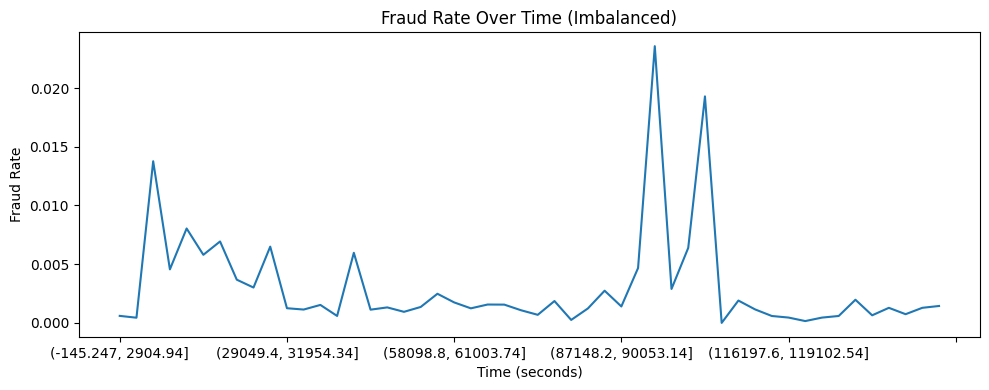

Imbalanced Dataset:
Number of Non-Fraud Transactions: 227428
Number of Fraud Transactions: 417
Balanced Dataset:
Number of Non-Fraud Transactions: 284315
Number of Fraud Transactions: 284315
Imbalanced dataset cells dropped: 0
Balanced dataset cells dropped: 0
Imbalanced dataset shape: ((182276, 30), (45569, 30), (182276,), (45569,))
Original fraud rate:   0.00183
Train fraud rate:      0.00183
Validation fraud rate: 0.00182
Fraud rates in train/validation sets match original dataset. Stratification successful.
Balanced dataset shape: ((182276, 30), (45569, 30), (182276,), (45569,))


In [ ]:
########################
# LOAD/CLEAN DATA      #
######################## 

import pandas as pd # should we import all necessary functions etc in this code block? I think so....
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit

# FOR LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report, precision_recall_curve, average_precision_score, confusion_matrix, roc_curve, auc
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold


# Load datasets
creditCard_imbalance = pd.read_csv('creditcard_imbalanced.csv')
creditCard_balance = pd.read_csv('creditcard_2023.csv')

# Plot and check for time-based patterns in the imbalanced dataset
time_bins = pd.cut(creditCard_imbalance['Time'], bins=50)
fraud_rate = creditCard_imbalance.groupby(time_bins)['Class'].mean()

plt.figure(figsize=(10, 4))
fraud_rate.plot()
plt.title('Fraud Rate Over Time (Imbalanced)')
plt.xlabel('Time (seconds)')
plt.ylabel('Fraud Rate')
plt.tight_layout()
plt.show()

# print number of fraud and non-fraud transactions in the imbalanced dataset
print("Imbalanced Dataset:")
print("Number of Non-Fraud Transactions:", creditCard_imbalance[creditCard_imbalance['Class'] == 0].shape[0])
print("Number of Fraud Transactions:", creditCard_imbalance[creditCard_imbalance['Class'] == 1].shape[0])   

# print number of fraud and non-fraud transactions in the balanced dataset
print("Balanced Dataset:")
print("Number of Non-Fraud Transactions:", creditCard_balance[creditCard_balance['Class'] == 0].shape[0])
print("Number of Fraud Transactions:", creditCard_balance[creditCard_balance['Class'] == 1].shape[0])   

# Clean data - Drop invalid rows (if any) and handle missing values
imb_missing_before = creditCard_imbalance.isna().sum().sum()
bal_missing_before = creditCard_balance.isna().sum().sum()

creditCard_imbalance = creditCard_imbalance.dropna()
creditCard_balance = creditCard_balance.dropna()

imb_missing_after = creditCard_imbalance.isna().sum().sum()
bal_missing_after = creditCard_balance.isna().sum().sum()

print(f"Imbalanced dataset cells dropped: {imb_missing_before - imb_missing_after}")
print(f"Balanced dataset cells dropped: {bal_missing_before - bal_missing_after}")

N_splits = 1
Test_size = 0.2

# Split data (numeric columns only for model training)
X_imbalanced = creditCard_imbalance.drop('Class', axis=1).select_dtypes(include=[np.number])
Y_imbalanced = creditCard_imbalance['Class']

# Use StratifiedShuffleSplit to split the imbalanced dataset
sss = StratifiedShuffleSplit(n_splits=N_splits, test_size=Test_size, random_state=42)
for train_index, test_index in sss.split(X_imbalanced, Y_imbalanced):
    X_train_imb, X_valid_imb = X_imbalanced.iloc[train_index], X_imbalanced.iloc[test_index]
    Y_train_imb, Y_valid_imb = Y_imbalanced.iloc[train_index], Y_imbalanced.iloc[test_index]
print(f'Imbalanced dataset shape: {X_train_imb.shape, X_valid_imb.shape, Y_train_imb.shape, Y_valid_imb.shape}')

# Sanity check that stratification worked - check fraud rates in original, train, and validation sets
print(f"Original fraud rate:   {Y_imbalanced.mean():.4f}")
print(f"Train fraud rate:      {Y_train_imb.mean():.4f}")
print(f"Validation fraud rate: {Y_valid_imb.mean():.4f}") 
if not np.isclose(Y_imbalanced.mean(), Y_train_imb.mean(), rtol=1e-2) or not np.isclose(Y_imbalanced.mean(), Y_valid_imb.mean(), rtol=1e-2):
    print("Warning: Fraud rates in train/validation sets do not match original dataset. Check stratification.")
else:
    print("Fraud rates in train/validation sets match original dataset. Stratification successful.")

## Balanced dataset for exploratory work
X_balanced = creditCard_imbalance.drop('Class', axis=1).select_dtypes(include=[np.number])
Y_balanced = creditCard_imbalance['Class']

sss_balanced = StratifiedShuffleSplit(n_splits=N_splits, test_size=Test_size, random_state=42) 
for train_index, test_index in sss_balanced.split(X_balanced, Y_balanced):
    X_train_b, X_valid_b = X_balanced.iloc[train_index], X_balanced.iloc[test_index]
    Y_train_b, Y_valid_b = Y_balanced.iloc[train_index], Y_balanced.iloc[test_index]
    
print(f'Balanced dataset shape: {X_train_b.shape, X_valid_b.shape, Y_train_b.shape, Y_valid_b.shape}')

# Observations
The dataset is highly imbalanced, with fraud accounting for only 0.18% of transactions ($\frac{417}{227{,}428 + 417}$). We first plot the fraud rate over time to assess whether temporal structure exists in the data. While a notable spike in fraud rate is observed around the 87,000–116,000 second range, we opt against temporal splitting for two reasons: the validation set would capture an unrepresentative burst of fraud rather than the true underlying fraud rate, and since the hidden test set has unknown temporal structure, stratified splitting provides a more robust and generalizable operating point for threshold selection. We then clean the data by dropping any rows with missing values, of which there are none, and confirm data integrity. Finally, we perform a stratified random split (80/20) and verify that the fraud rate is preserved across the original, training, and validation sets at 0.18%.

# Logistic regression classifier

In order to design a good model for our specific use-case, several descions need to be made. The following is a brief explanations of the choices we've made.

Since logistic regression has a convex loss function advanced optimizers such as Adam are not necessary, instead we can use standard convex optimizer such as LBFGS. LBFGS is a quasi-Newton method which approximates an inverse Hessian matrix to steer its search.
#### Optimizer

Since logistic regression has a convex loss function advanced optimizers such as Adam are not nescessary, instead we can use standard convex optimizer such as LBFGS. LBFGS is a quasi-Newton method which approximates an inverse Hessian matrix to steer its search.


#### Regularization
The regularization parameter C is the inverse of the penalty strength in logistic regression. Its value controls the trade-off between goodness of fit and model complexity: a large C corresponds to weak regularization, whereas a small C imposes stronger regularization.

The appropriate level of regularization is typically selected empirically, since insufficient regularization may lead to overfitting, while excessive regularization may oversimplify the model and reduce predictive performance.


#### Termination
A key question that arises when we are using a numerical optimizer is when to stop (is this optimal enough?). 

A common approach is to stop the training when we have hit a maxinum number of iterations (upper bound). However, with this approach there is no guarantee of the quality of the final weights. Therefore we need to combine with another termination criterion (|gradient| < t) (lower bound). 

In [ ]:
########################
# LOGISTIC REGRESSION  #
########################

# Step 1, explain ....
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # is this going to be the same when training all of our models, in that case maybe it should be in the common first coding block

pipe_lr = make_pipeline(
    StandardScaler(), # for numerical stability
    LogisticRegression(random_state=42)
)

# Step 2: Hyperparameters for logistic regression
param_dist = {
    "logisticregression__C": [0.01, 0.1, 1, 10],
    "logisticregression__class_weight": [None, "balanced"],
    "logisticregression__solver": ["lbfgs"],
    "logisticregression__tol": [1e-4],
    "logisticregression__max_iter": [1000, 3000]
}


random_search_lr = RandomizedSearchCV(
    estimator=pipe_lr,
    param_distributions=param_dist,
    n_iter=10,
    cv=cv,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

# Step 3: Training our model 
random_search_lr.fit(X_train_imb, Y_train_imb)
best_log_reg = random_search_lr.best_estimator_
Y_pred_imb_lr = best_log_reg.predict(X_valid_imb)

# Step 4: Report values
print("Best params:", random_search_lr.best_params_)
print("=== Validation report, threshold = 0.5 ===")
print(classification_report(Y_valid_imb, Y_pred_imb_lr))

tn_lr, fp_lr, fn_lr, tp_lr = confusion_matrix(Y_valid_imb, Y_pred_imb_lr).ravel()

fpr_lr = fp_lr / (fp_lr + tn_lr)
print(f"False alarm rate (FPR): {fpr_lr:.6f}")

Best params: {'logisticregression__tol': 0.0001, 'logisticregression__solver': 'lbfgs', 'logisticregression__max_iter': 3000, 'logisticregression__class_weight': None, 'logisticregression__C': 10}
=== Validation report, threshold = 0.5 ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     45486
           1       0.81      0.66      0.73        83

    accuracy                           1.00     45569
   macro avg       0.90      0.83      0.86     45569
weighted avg       1.00      1.00      1.00     45569

False alarm rate (FPR): 0.000286


### Interpretation of the logistic regression result

The standard logistic regression model performs very well on the majority class (non-fraud), which is expected because this class dominates the dataset. For class 0, both precision and recall are essentially perfect. However, the performance on the minority class (fraud) is clearly weaker. The most concerning measure is the recall rate, where 34% of fraud cases are not detected. This suggest that a purely linear descision boundary is too restrictive and motivates exploring more expressive models, such as polynomial logistic regression.

The regularization weights that yielded the best results for this model were C = 0.1 or 1 (results from several runs with randomized search). This suggest that a moderate amount of regularization is beneficial for the model as it obtains a balance between model flexibility and complexity.

### Polynomial logistic regression
To explore wether a non-linear model might perform better, we expand our model to a feature space of degreee = 2.

In [21]:
##################################
# POLYNOMIAL LOGISTIC REGRESSION #
##################################

pipe_plr = make_pipeline(
    PolynomialFeatures(include_bias=False),
    StandardScaler(),
    LogisticRegression(random_state=42)
)
# Step 2: Hyperparameters
param_dist = {
    "polynomialfeatures__degree": [2],
    "logisticregression__C": [0.01, 0.1, 1, 10, 100, 200],
    "logisticregression__class_weight": [None, "balanced"],
    "logisticregression__solver": ["lbfgs"],
    "logisticregression__tol": [1e-4],
    "logisticregression__max_iter": [2000, 3000, 4000]
}

random_search_poly_plr = RandomizedSearchCV(
    estimator=pipe_plr,
    param_distributions=param_dist,
    n_iter=10,
    cv=cv,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

# Step 3: Training our model 
random_search_poly_plr.fit(X_train_imb, Y_train_imb)
best_model = random_search_poly_plr.best_estimator_


Y_pred_imb_plr = best_model.predict(X_valid_imb)
Y_prob_imb_plr = best_model.predict_proba(X_valid_imb)[:, 1]

# Step 4: Report values
print("Best params:", random_search_poly_plr.best_params_)
print("=== Validation report, threshold = 0.5 ===")
print(classification_report(Y_valid_imb, Y_pred_imb_plr))


tn_plr, fp_plr, fn_plr, tp_plr = confusion_matrix(Y_valid_imb, Y_pred_imb_plr).ravel()

fpr_plr = fp_plr / (fp_plr + tn_plr)
print(f"False alarm rate (FPR): {fpr_plr:.6f}")

/Users/asneomland/Documents/NTNU/Utveksling/Var_2026/EDK/EECE564_A3/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'polynomialfeatures__degree': 2, 'logisticregression__tol': 0.0001, 'logisticregression__solver': 'lbfgs', 'logisticregression__max_iter': 4000, 'logisticregression__class_weight': None, 'logisticregression__C': 0.1}
=== Validation report, threshold = 0.5 ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     45486
           1       0.86      0.87      0.86        83

    accuracy                           1.00     45569
   macro avg       0.93      0.93      0.93     45569
weighted avg       1.00      1.00      1.00     45569

False alarm rate (FPR): 0.000264


### Interpretation of the polynomial logistic regression result

The results indicate that logistic regression with polynomial features of degree 2 performs better than standard logistic regression, which corresponds to degree 1. This suggests that the relationship between the input features and the class label is not purely linear, and that the model benefits from including quadratic terms and pairwise feature interactions. The kernelized version allows the classifier to represent more complex decision boundaries, which appears to improve performance on the validation set.

The best-performing degree-2 model used a relatively small regularization parameter, C=0.1, together with a large maximum number of iterations. Since C is the inverse of the regularization strength, a smaller value of C means stronger regularization. This is reasonable here, because polynomial expansion increases the number of features substantially and therefore also increases the risk of overfitting. Stronger regularization helps control the model complexity and improves generalization.

Overall, the results suggest that adding second-order polynomial features captures useful nonlinear structure in the data and leads to better classification performance than the purely linear model.


# Random Forest
The Random Forest classifier is an ensemble supervised learning method. This classifier uses multiple decision trees during training and combines their outputs into a singular result. Overfitting and bias is corrected by virtue of having multiple decision trees (ie the ensemble method). However, Random Forest classifiers are more computationally expensive, complex and time-consuming than individual trees and linear regression. Nevertheless, their performance justifies said considerations. 

## Hyperparameters
The hyperparameters tuned are listed below:
- `n_estimators` (default: 100): Number of decision trees in the forest. More trees improve stability and reduce variance, but increase computational 
cost. Too few trees risk instability and underfitting.
- `max_depth` (default: None): Maximum depth of each decision tree. Shallow trees may underfit the data while unconstrained trees may overfit, particularly on noisy datasets. By default, upper-bounded until leaf node is pure (node in tree contains training samples that belong only in single class, with zero classification uncertainty) or until all leaves contain less than `min_samples_split` samples
- `max_features` (default: `sqrt`): Number of features considered at each tree node split. Limiting this introduces randomness between trees, reducing correlation and improving generalization. Having higher `max_features` risks overfitting.
- `min_samples_leaf` (default: 1): Minimum number of samples required at a leaf node. Larger values smooth the model and reduce overfitting by preventing splits on very small subsets of data.
- `class_weight` (default: None): Assigns weights to each class during training. Setting this to `balanced` penalizes misclassification of the minority class more heavily, which can improve recall on imbalanced datasets.

While several other hyperparameters exist, those listed above are typically the most influential on model performance. We create the parameters distribution as shown in the code below and the ranges were determined through trial-and-error.

## Scoring
Having established the hyperparameters to tune, we must select a relevant benchmark metric. Some considerations are listed below, with the chosen 
metric **bolded**:
- Precision: The fraction of predicted fraud cases that are actually fraud. High precision minimizes false alarms but may miss true fraud cases.

$\begin{aligned}
Precision &= \frac{TP}{TP+FP}
\end{aligned}$
- Recall: The fraction of actual fraud cases that are correctly detected. High recall minimizes missed fraud but may increase false alarms.

$\begin{aligned}
Recall &= \frac{TP}{TP+FN}
\end{aligned}$
- Accuracy: The fraction of all transactions correctly classified. Misleading under severe class imbalance — a model that predicts no fraud achieves 99.82% accuracy on this dataset.

$\begin{aligned}
Accuracy &= \frac{TP+TN}{TP+FN+TN+FP}
\end{aligned}$
- **F1**: Harmonic mean of precision and recall. Provides a balanced metric that accounts for both false positives and false negatives, making it well-suited for imbalanced datasets.

$\begin{aligned}
F1 &= \frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
\end{aligned}$

## Hyperparameter Tuning
To tune the hyperparameters above, two methods were considered:
- `GridSearchCV`: Exhaustively searches all combinations within a defined parameter grid, optimizing the scoring metric via cross-validation. Guarantees finding the best combination but is computationally expensive.
- `RandomizedSearchCV`: Randomly samples a fixed number of combinations from a defined parameter space, optimizing the scoring metric via cross-validation. Substantially reduces computational cost at the expense of exhaustiveness.

`RandomizedSearchCV` was chosen as it substantially reduces the 
computational cost of hyperparameter tuning while still exploring the 
parameter space effectively.

## Benchmarking
After hyperparameter tuning, the model is retrained on the full training set using the optimal hyperparameters. As a sanity check, we evaluate performance on the validation set at the default threshold of 0.5 before proceeding to threshold selection.

In [ ]:
########################
# RANDOM FOREST        #
########################

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit,RandomizedSearchCV
from sklearn.metrics import f1_score

# Step 1 — Train/validation split
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, val_index in sss.split(X_imbalanced, Y_imbalanced):
    X_train_imb = X_imbalanced.iloc[train_index]
    X_val_imb   = X_imbalanced.iloc[val_index]
    Y_train_imb = Y_imbalanced.iloc[train_index]
    Y_val_imb   = Y_imbalanced.iloc[val_index]

# Keep only numeric columns to avoid dtype errors in sklearn
X_train_imb = X_train_imb.select_dtypes(include=['number'])
X_val_imb = X_val_imb[X_train_imb.columns]

# Sanity check
print(f"Original fraud rate:   {Y_imbalanced.mean():.4f}")
print(f"Train fraud rate:      {Y_train_imb.mean():.4f}")
print(f"Validation fraud rate: {Y_val_imb.mean():.4f}") 

# Step 2 — Hyperparameter tuning via Stratified K-Fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) 

# Phase 1 — wide random search
param_dist = {
    'n_estimators':     [100, 120, 150],    # center around 120 (from previous experiments)
    'max_depth':        [8, 10, 12],        # center around 10 (from previous experiments)
    'max_features':     ['sqrt', 'log2'],   
    'min_samples_leaf': [1, 2, 5],          
    'class_weight':     [None]              # already know balanced loses (from previous experiments)
}

import time

start = time.time()
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=10,
    cv=cv,
    scoring='f1',
    n_jobs=1,
    random_state=42,
    verbose=1
)
random_search.fit(X_train_imb, Y_train_imb)
end = time.time()

print(f"Elapsed time: {(end - start)/60:.2f} minutes")
print(f"Best params so far: {random_search.best_params_}")


Original fraud rate:   0.0018
Train fraud rate:      0.0018
Validation fraud rate: 0.0018
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Elapsed time: 159.39 minutes
Best params so far: {'n_estimators': 120, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10, 'class_weight': None}


In [9]:
### Load to avoid retuning:
# Best params: {'n_estimators': 120, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10, 'class_weight': None}
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report

# Step 1 — Train/validation split
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, val_index in sss.split(X_imbalanced, Y_imbalanced):
    X_train_imb = X_imbalanced.iloc[train_index]
    X_val_imb   = X_imbalanced.iloc[val_index]
    Y_train_imb = Y_imbalanced.iloc[train_index]
    Y_val_imb   = Y_imbalanced.iloc[val_index]

# Keep only numeric columns
X_train_imb = X_train_imb.select_dtypes(include=['number'])
X_val_imb   = X_val_imb[X_train_imb.columns]

# Sanity check
print(f"Original fraud rate:   {Y_imbalanced.mean():.4f}")
print(f"Train fraud rate:      {Y_train_imb.mean():.4f}")
print(f"Validation fraud rate: {Y_val_imb.mean():.4f}")

# Step 2 — Instantiate with best known params
best_rf = RandomForestClassifier(
    n_estimators=120,
    min_samples_leaf=1,
    max_features='sqrt',
    max_depth=10,
    class_weight=None,
    random_state=42,
    n_jobs=-1
)

Original fraud rate:   0.0018
Train fraud rate:      0.0018
Validation fraud rate: 0.0018


In [12]:
best_rf.fit(X_train_imb, Y_train_imb)
Y_pred_imb = best_rf.predict(X_val_imb)
print(classification_report(Y_val_imb, Y_pred_imb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     45486
           1       0.97      0.81      0.88        83

    accuracy                           1.00     45569
   macro avg       0.99      0.90      0.94     45569
weighted avg       1.00      1.00      1.00     45569



# Observations
At the default threshold of 0.5, the model performs near-perfectly on the non-fraud class (precision, recall, and F1 all at 1.00), which is expected given the heavy class imbalance since the model sees overwhelmingly more 
non-fraud examples during training. Performance on the fraud class is naturally lower, with precision of 0.97 and recall of 0.81, and F1 
score of 0.88. This is considered strong for a <<1% imbalanced dataset and suggests the model generalizes well without overfitting.

The recall of 0.81 indicates that approximately 1 in 5 fraud cases are missed at the default threshold. This is expected and will be addressed in the threshold selection step, where we lower the decision boundary to increase fraud detection at the cost of more false alarms.

Overall accuracy of 1.00 is uninformative here, as a trivial classifier that never predicts fraud would achieve 99.82% accuracy. The macro (unweighted) average F1 of 0.94 averages performance equally across both classes and is pulled down by the fraud class F1 of 0.88. The weighted average F1 of 1.00 weights by class support and is therefore dominated by the 45,486 non-fraud samples, making it an equally uninformative metric under this degree of imbalance. The macro average is the more honest summary of overall model performance.

# **Task C.2 - Hard-decision threshold selection**

We determine two thresholds $\eta_1, \eta_2$ such that
$$\begin{aligned}
\eta_1 &\rightarrow P_{FA} \approx 0.01 \\
\eta_2 &\rightarrow P_{FA} \approx 0.001 
\end{aligned}$$
To achieve $\eta_1, \eta_2$, we consider two curves:
- Receiver-Operating-Characteristic (ROC): This curve plots sensitivity (true positive rate) on the vertical axis and its complement (false sensitivity rate) on the horizontal axis
- Precision-Recall (PR): This curves plot Precision on the vertical axis and Recall on the horizontal axis. Precision is defined as 
We achieve the thresholds empirically for the Random Forest model since it is non-parametric. 


### Metrics to determine quality of model

In addition to the measuring the quality of model with presiscion, recall, F1-score and false-alarm rate. We will also use ROC's to determine wether the model performs given certain thresholds. To compare how the thresholds perform we'll also calculate the optimal threshold in this task.

##### ROC: Receiver Operating Characteristic
It is a curve used to evaluate a binary classification model by showing how the model behaves as we vary the decision threshold $\eta$. It plots the true-positive rate (y-axis) against the false-positive rate (x_axis). A good model should have a high true-positive rate and a low false-positive rate. The area under curve value (AUC) should be as close to 1 as possible.


## Logistic regression threshold selection

So far we have made our model with $\eta$ = 0.5, this have given us a pretty low false alarm rate. For logistic regression with polynomial degree 1 the PFA = 0.000286, and for logistic regression with polynomial dregree 2 the PFA was slightly lower with a value equal to 0.000264.

Since the logistic regression with polynomiel degree 2 overall has the best performance (F1-score, prescision etc.), that is the one we will be using for determining the threshold value.

In [34]:
######################################################
# POLYNOMIAL LOGISTIC REGRESSION THRESHOLD SELECTION #
######################################################

PFA_1 = 0.01 # probability false alarm rates
PFA_2 = 0.001

# ROC curves
fpr, tpr, roc_thresholds = roc_curve(Y_valid_imb, Y_prob_imb_plr)

idx_1 = np.argmin(np.abs(fpr - PFA_1))
idx_2 = np.argmin(np.abs(fpr - PFA_2))
eta_1 = roc_thresholds[idx_1]
eta_2 = roc_thresholds[idx_2]

print(f"η1 (Probability false alarm ≈ {PFA_1} ): {eta_1:.5f} actual FPR: {fpr[idx_1]:.5f} TPR:  {tpr[idx_1]:.5f}")
print(f"η2 (Probability false alarm ≈ {PFA_2}): {eta_2:.5f} actual FPR: {fpr[idx_2]:.5f} TPR:  {tpr[idx_2]:.5f}")

# Hard descision pedictions
Y_pred_lrk_1 = (Y_prob_imb_plr >= eta_1).astype(int) # returns predicted labels given threshold
Y_pred_lrk_2 = (Y_prob_imb_plr >= eta_2).astype(int) 

# F1 score
f1_lrk_1 = f1_score(Y_valid_imb, Y_pred_lrk_1, average='macro')
f1_lrk_2 = f1_score(Y_valid_imb, Y_pred_lrk_2, average='macro')
 
print()
print(f"F1 Score: {f1_lrk_1:.5f} with η1 = {eta_1:.5f}")
print(f"F1 Score: {f1_lrk_2:.5f} with η2 = {eta_2:.5f}")


# Evaluate hard decisions at each threshold
for name, eta, idx in [('η1', eta_1, idx_1), ('η2', eta_2, idx_2)]:
    Y_pred_thresh = (Y_prob_imb_plr >= eta).astype(int)
    print(f"\nClassification report at {name} (threshold={eta:.5f}):")
    print(classification_report(Y_valid_imb, Y_pred_thresh))


η1 (Probability false alarm ≈ 0.01 ): 0.00234 actual FPR: 0.01570 TPR:  0.91566
η2 (Probability false alarm ≈ 0.001): 0.60763 actual FPR: 0.00020 TPR:  0.85542

F1 Score: 0.58306 with η1 = 0.00234
F1 Score: 0.93547 with η2 = 0.60763

Classification report at η1 (threshold=0.00234):
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     45486
           1       0.10      0.92      0.17        83

    accuracy                           0.98     45569
   macro avg       0.55      0.95      0.58     45569
weighted avg       1.00      0.98      0.99     45569


Classification report at η2 (threshold=0.60763):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     45486
           1       0.89      0.86      0.87        83

    accuracy                           1.00     45569
   macro avg       0.94      0.93      0.94     45569
weighted avg       1.00      1.00      1.00     45569



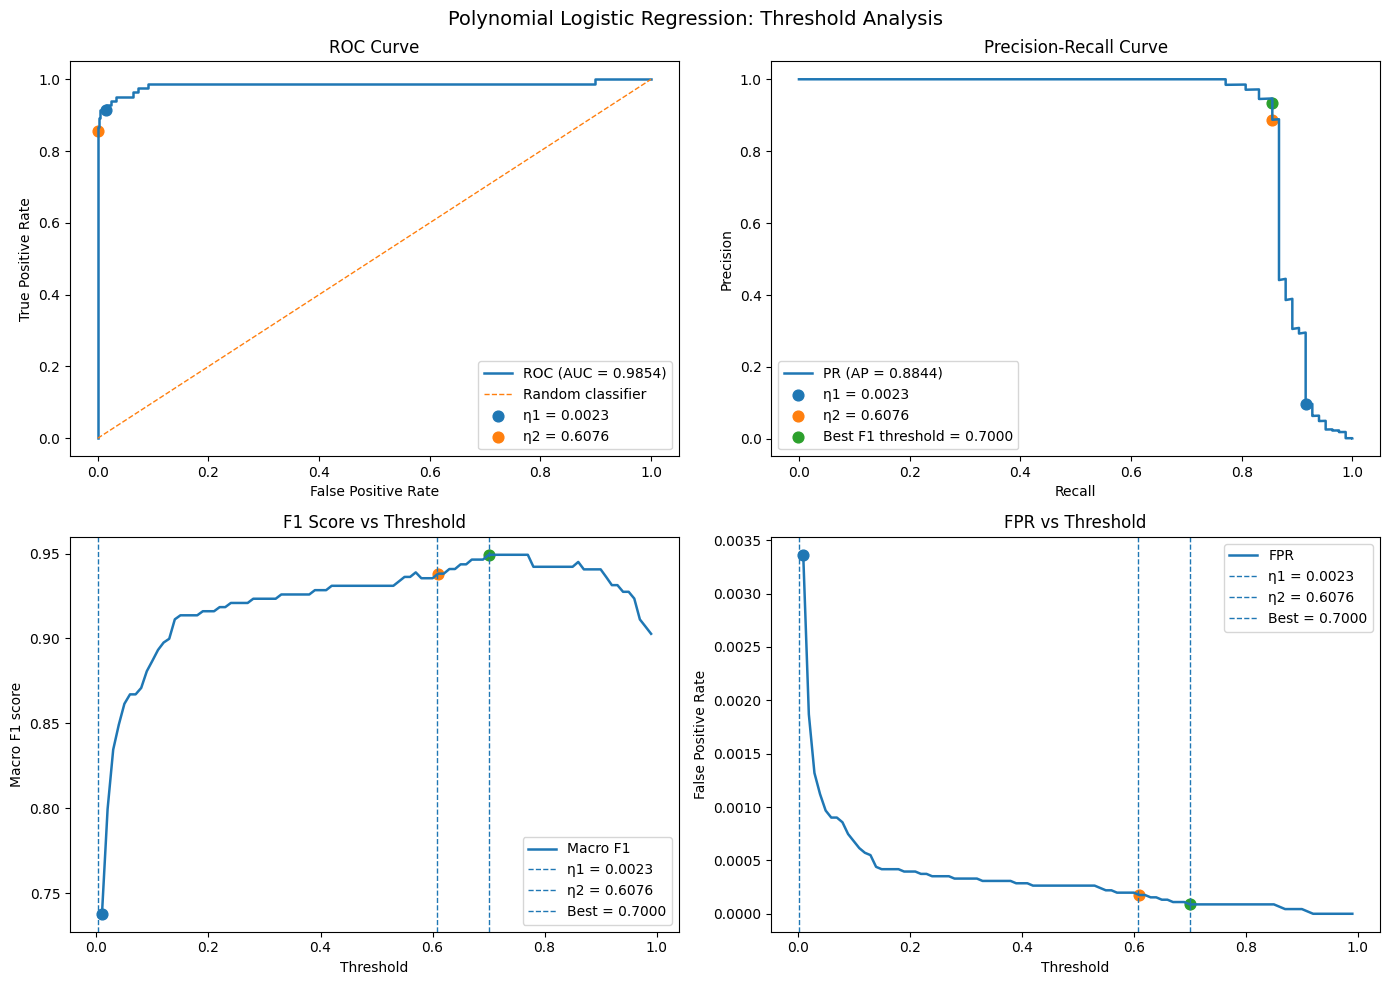

In [ ]:
####################
# VISUALIZING DATA #
####################
roc_auc = auc(fpr, tpr)
precision, recall, pr_thresholds = precision_recall_curve(Y_valid_imb, Y_prob_imb_plr)
ap = average_precision_score(Y_valid_imb, Y_prob_imb_plr)

candidate_thresholds = np.linspace(0.01, 0.99, 99)

f1_scores = []
fpr_vs_threshold = []

for t in candidate_thresholds:
    y_pred_t = (Y_prob_imb_plr >= t).astype(int)

    # Macro F1 for consistency with your current code
    f1_scores.append(f1_score(Y_valid_imb, y_pred_t, average='macro'))

    tn, fp, fn, tp = confusion_matrix(Y_valid_imb, y_pred_t).ravel()
    fpr_t = fp / (fp + tn)
    fpr_vs_threshold.append(fpr_t)

f1_scores = np.array(f1_scores)
fpr_vs_threshold = np.array(fpr_vs_threshold)

# Best threshold from F1
best_idx = np.argmax(f1_scores) # choosing the eta that maximized the F1-score
best_threshold = candidate_thresholds[best_idx]
best_f1 = f1_scores[best_idx]

# --------------------------------------------------
# 3. Helper indices for marking η1, η2, and best threshold
# --------------------------------------------------
# ROC indices
roc_idx_eta1 = np.argmin(np.abs(roc_thresholds - eta_1))
roc_idx_eta2 = np.argmin(np.abs(roc_thresholds - eta_2))
roc_idx_best = np.argmin(np.abs(roc_thresholds - best_threshold))

# PR indices
# note: pr_thresholds has length len(precision)-1
pr_idx_eta1 = np.argmin(np.abs(pr_thresholds - eta_1))
pr_idx_eta2 = np.argmin(np.abs(pr_thresholds - eta_2))
pr_idx_best = np.argmin(np.abs(pr_thresholds - best_threshold))

# Threshold-grid indices
grid_idx_eta1 = np.argmin(np.abs(candidate_thresholds - eta_1))
grid_idx_eta2 = np.argmin(np.abs(candidate_thresholds - eta_2))

# --------------------------------------------------
# 4. Plot all four panels
# --------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ---------------- ROC ----------------
ax = axes[0, 0]
ax.plot(fpr, tpr, lw=1.8, label=f'ROC (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], '--', lw=1, label='Random classifier')
ax.scatter(fpr[roc_idx_eta1], tpr[roc_idx_eta1], s=60,
           label=f'η1 = {eta_1:.4f}')
ax.scatter(fpr[roc_idx_eta2], tpr[roc_idx_eta2], s=60,
           label=f'η2 = {eta_2:.4f}')
ax.scatter(fpr[roc_idx_best], tpr[roc_idx_best], s=60,
           label=f'Best F1 threshold = {best_threshold:.4f}')

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend()

# ---------------- PR ----------------
ax = axes[0, 1]
ax.plot(recall, precision, lw=1.8, label=f'PR (AP = {ap:.4f})')

ax.scatter(recall[pr_idx_eta1], precision[pr_idx_eta1], s=60,
           label=f'η1 = {eta_1:.4f}')
ax.scatter(recall[pr_idx_eta2], precision[pr_idx_eta2], s=60,
           label=f'η2 = {eta_2:.4f}')
ax.scatter(recall[pr_idx_best], precision[pr_idx_best], s=60,
           label=f'Best F1 threshold = {best_threshold:.4f}')

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
ax.legend()

# ---------------- F1 vs threshold ----------------
ax = axes[1, 0]
ax.plot(candidate_thresholds, f1_scores, lw=1.8, label='Macro F1')

ax.axvline(eta_1, linestyle='--', lw=1, label=f'η1 = {eta_1:.4f}')
ax.axvline(eta_2, linestyle='--', lw=1, label=f'η2 = {eta_2:.4f}')
ax.axvline(best_threshold, linestyle='--', lw=1, label=f'Best = {best_threshold:.4f}')

ax.scatter(candidate_thresholds[grid_idx_eta1], f1_scores[grid_idx_eta1], s=60)
ax.scatter(candidate_thresholds[grid_idx_eta2], f1_scores[grid_idx_eta2], s=60)
ax.scatter(candidate_thresholds[best_idx], f1_scores[best_idx], s=60)

ax.set_xlabel("Threshold")
ax.set_ylabel("Macro F1 score")
ax.set_title("F1 Score vs Threshold")
ax.legend()

# ---------------- FPR vs threshold ----------------
ax = axes[1, 1]
ax.plot(candidate_thresholds, fpr_vs_threshold, lw=1.8, label='FPR')

ax.axvline(eta_1, linestyle='--', lw=1, label=f'η1 = {eta_1:.4f}')
ax.axvline(eta_2, linestyle='--', lw=1, label=f'η2 = {eta_2:.4f}')
ax.axvline(best_threshold, linestyle='--', lw=1, label=f'Best = {best_threshold:.4f}')

ax.scatter(candidate_thresholds[grid_idx_eta1], fpr_vs_threshold[grid_idx_eta1], s=60)
ax.scatter(candidate_thresholds[grid_idx_eta2], fpr_vs_threshold[grid_idx_eta2], s=60)
ax.scatter(candidate_thresholds[best_idx], fpr_vs_threshold[best_idx], s=60)

ax.set_xlabel("Threshold")
ax.set_ylabel("False Positive Rate")
ax.set_title("FPR vs Threshold")
ax.legend()

plt.suptitle("Polynomial Logistic Regression: Threshold Analysis", fontsize=14)
plt.tight_layout()
plt.show()


### Interpretations of polynomial logistic regression threshold determination

#### ROC curve
AUC = 0.9854 is a strong value that ... the model has a high true-positive (TPR) rate while keeping a low false-positive rate (FPR). $\eta_1$ which has a higher FPR also achieves a higher TPR, this was excpected. Whether this is desirable depends on how important it minimize the FPR. $\eta_2$ has both a lower FPR and TPR, and is overlapping with the best threshold value (that is chosen based on F1-score).

#### F1 curve
The f1-score has its maximum close to 0.95. $\eta_1$ performs exceptionally bad with a very low f1-score, while $\eta_2$ is close to the optimal value.

#### PR curve
With an average precision (AP) = 0.8844 this model maintains high precision over a wide range of recall values. Also here we see that $\eta_2$ performs better, with both high presiscion and recall values, while  $\eta_1$ has a concerning low precision value.


#### FPR
WHen the threshold is low, many fraud observations are wrongly classified as legit. That is why FPR is high close to zero, and the dereases as the threshold increases. Also here does $\eta_2$ perform better than $\eta_1$, as it achieves a much lower FPR.

#### Conclusion
The polynomial logistic regression model shows excellent discriminative ability when the threshold is above 0.5. Threshold tuning indicates that a decision threshold of 0.70 gives the best balance between precision and recall, achieving the highest macro F1 score (about 0.95) while keeping the false positive rate close to zero. This suggests that the model is both accurate and robust.



Ivan's Markdown
In this section below, we determine the threshold 

η1 — PFA ≈ 0.01:  threshold = 0.0038 | actual PFA = 0.0091 | TPR = 0.8554
η2 — PFA ≈ 0.001: threshold = 0.3917 | actual PFA = 0.0002 | TPR = 0.8313


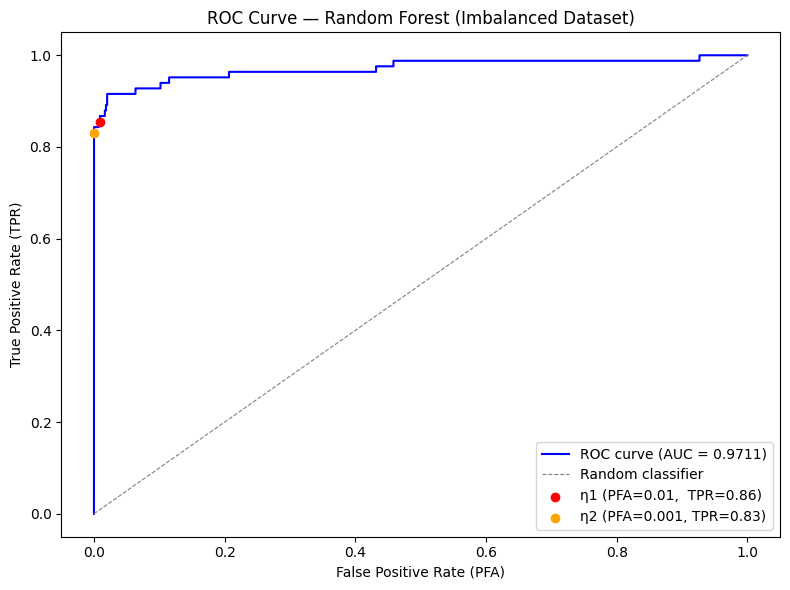


Classification report at η1 (threshold=0.0038):
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     45486
           1       0.15      0.86      0.25        83

    accuracy                           0.99     45569
   macro avg       0.57      0.92      0.62     45569
weighted avg       1.00      0.99      0.99     45569


Classification report at η2 (threshold=0.3917):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     45486
           1       0.91      0.83      0.87        83

    accuracy                           1.00     45569
   macro avg       0.95      0.92      0.93     45569
weighted avg       1.00      1.00      1.00     45569



In [13]:
########################
# ROC & THRESHOLDS     #
########################
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Get predicted probabilities on validation set
y_scores = best_rf.predict_proba(X_val_imb)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(Y_val_imb, y_scores)
roc_auc = auc(fpr, tpr)

# Find η1 (PFA ≈ 0.01) and η2 (PFA ≈ 0.001)
idx1 = np.argmin(np.abs(fpr - 0.01))
idx2 = np.argmin(np.abs(fpr - 0.001))

eta1 = thresholds[idx1]
eta2 = thresholds[idx2]

print(f"η1 — PFA ≈ 0.01:  threshold = {eta1:.4f} | actual PFA = {fpr[idx1]:.4f} | TPR = {tpr[idx1]:.4f}")
print(f"η2 — PFA ≈ 0.001: threshold = {eta2:.4f} | actual PFA = {fpr[idx2]:.4f} | TPR = {tpr[idx2]:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=1.5, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=0.8, label='Random classifier')

# Mark thresholds
plt.scatter(fpr[idx1], tpr[idx1], color='red',    zorder=5, label=f'η1 (PFA=0.01,  TPR={tpr[idx1]:.2f})')
plt.scatter(fpr[idx2], tpr[idx2], color='orange', zorder=5, label=f'η2 (PFA=0.001, TPR={tpr[idx2]:.2f})')

plt.xlabel('False Positive Rate (PFA)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve — Random Forest (Imbalanced Dataset)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Evaluate hard decisions at each threshold
for name, eta, idx in [('η1', eta1, idx1), ('η2', eta2, idx2)]:
    Y_pred_thresh = (y_scores >= eta).astype(int)
    print(f"\nClassification report at {name} (threshold={eta:.4f}):")
    print(classification_report(Y_val_imb, Y_pred_thresh))

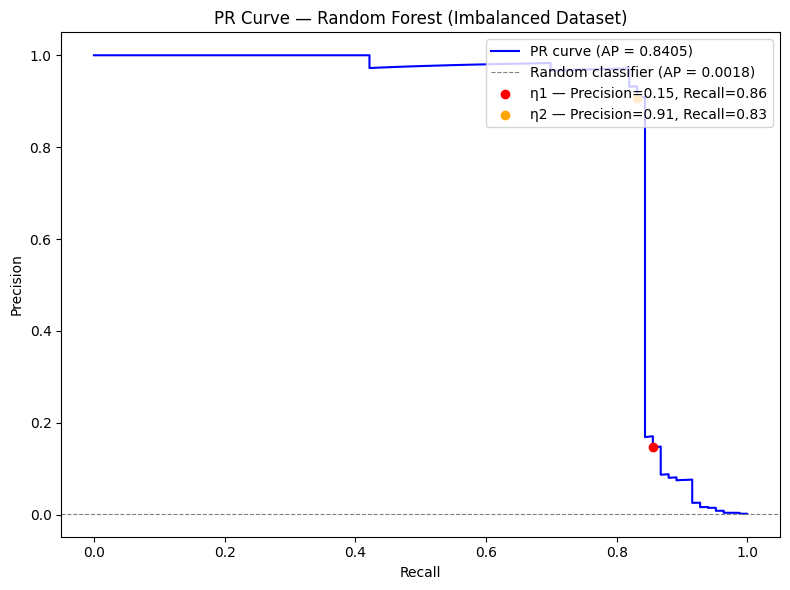

Average Precision (AP): 0.8405
Baseline AP (random):   0.0018
Improvement over random: 461.5x


In [14]:
########################
# PR CURVE             #
########################
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, pr_thresholds = precision_recall_curve(Y_val_imb, y_scores)
ap = average_precision_score(Y_val_imb, y_scores)

# Find PR points closest to η1 and η2
idx_pr1 = np.argmin(np.abs(pr_thresholds - eta1))
idx_pr2 = np.argmin(np.abs(pr_thresholds - eta2))

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=1.5, label=f'PR curve (AP = {ap:.4f})')
plt.axhline(y=Y_val_imb.mean(), color='gray', linestyle='--', lw=0.8, label=f'Random classifier (AP = {Y_val_imb.mean():.4f})')

# Mark η1 and η2
plt.scatter(recall[idx_pr1], precision[idx_pr1], color='red',    zorder=5, label=f'η1 — Precision={precision[idx_pr1]:.2f}, Recall={recall[idx_pr1]:.2f}')
plt.scatter(recall[idx_pr2], precision[idx_pr2], color='orange', zorder=5, label=f'η2 — Precision={precision[idx_pr2]:.2f}, Recall={recall[idx_pr2]:.2f}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR Curve — Random Forest (Imbalanced Dataset)')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f"Average Precision (AP): {ap:.4f}")
print(f"Baseline AP (random):   {Y_val_imb.mean():.4f}")
print(f"Improvement over random: {ap / Y_val_imb.mean():.1f}x")

Ivan's Markdown
From the ROC curves above, observe that... In contrast to... This could be due to...

# **Task C.3 - Calibration**
To calibrate the data, we consider:
- Platt Scaling
- Isotonic Regression
- Spline Calibration

In [3]:
# Platt Scaling
# from sklearn.calibration import CalibratedClassifierCV  


In [ ]:
# Isotonic Regression

In [ ]:
# Spline Calibration